In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

from scipy import stats

# Project task 1: Data import and organization

Import data, transform it to make it more readable and save it.

In [2]:
# Step 1: Loading the dataset
diabetes = load_diabetes(scaled=False)
df_diabetes_raw = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
df_diabetes_raw['target'] = diabetes.target

# Step 2: Rename columns to meaningful labels.
rename_map = {
    "age":    "Age",
    "sex":    "Gender",
    "bmi":    "BMI",
    "bp":     "BP",
    "s1":     "TC",
    "s2":     "LDL",
    "s3":     "HDL",
    "s4":     "TCH",
    "s5":     "LTG",
    "s6":     "Glu",
    "target": "Progression",
}
df_diabetes_raw = df_diabetes_raw.rename(columns=rename_map)

# Step 3: Replace the default integer index.
df_diabetes_raw.index = [f"Patient_ID_{x:03}" for x in range(len(df_diabetes_raw))]

# Step 4: Re-encoding the values in the Gender column.
df_diabetes_raw["Gender"] = df_diabetes_raw["Gender"].astype("string")
df_diabetes_raw["Gender"] = df_diabetes_raw["Gender"].replace({
    "1.0":"Female",
    "2.0":"Male"
})
df_diabetes_raw

,Age,Gender,BMI,BP,TC,LDL,HDL,TCH,LTG,Glu,Progression
Patient_ID_000,59.0,Male,32.1,101.00,157.0,93.2,38.0,4.00,4.8598,87.0,151.0
Patient_ID_001,48.0,Female,21.6,87.00,183.0,103.2,70.0,3.00,3.8918,69.0,75.0
Patient_ID_002,72.0,Male,30.5,93.00,156.0,93.6,41.0,4.00,4.6728,85.0,141.0
Patient_ID_003,24.0,Female,25.3,84.00,198.0,131.4,40.0,5.00,4.8903,89.0,206.0
Patient_ID_004,50.0,Female,23.0,101.00,192.0,125.4,52.0,4.00,4.2905,80.0,135.0
...,...,...,...,...,...,...,...,...,...,...,...
Patient_ID_437,60.0,Male,28.2,112.00,185.0,113.8,42.0,4.00,4.9836,93.0,178.0
Patient_ID_438,47.0,Male,24.9,75.00,225.0,166.0,42.0,5.00,4.4427,102.0,104.0
Patient_ID_439,60.0,Male,24.9,99.67,162.0,106.6,43.0,3.77,4.1271,95.0,132.0
Patient_ID_440,36.0,Female,30.0,95.00,201.0,125.2,42.0,4.79,5.1299,85.0,220.0


In [3]:
#Step 5: Separate the df_diabetes_raw data frame to two data frames
df_diabetes_metadata = df_diabetes_raw[["Age", "Gender"]]
df_diabetes_features = df_diabetes_raw[['BMI', 'BP', 'TC', 'LDL', 'HDL',
'TCH', 'LTG', 'Glu','Progression']]

#Step 6: Save the two data frames as Excel files
df_diabetes_features.to_excel("df_diabetes_features.xlsx")
df_diabetes_metadata.to_excel("Table_diabetes_metadata.xlsx")

# Project task 2: Visualizing the data

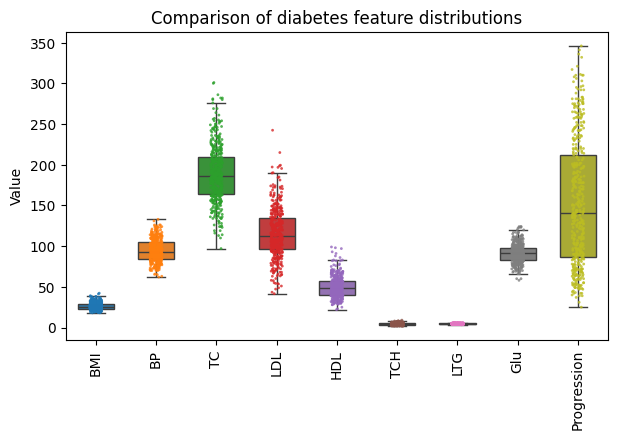

In [4]:
#Step 1: Make box-plots to visualize and compare the distribution of the raw (!) values of all the features in df_diabetes_features

plt.figure(figsize=(7, 4))
sns.boxplot(data=df_diabetes_features, showfliers=False, width=0.6)
sns.stripplot(data=df_diabetes_features, alpha=0.8, legend=False, size=2)
plt.ylabel("Value")
plt.xticks(rotation=90)
plt.title("Comparison of diabetes feature distributions")
plt.show()
plt.close()

The box plots are created to explore and compare the distributions of all features before any preprocessing. It is helpful for many reasons like detecting Scale Differences, Identifying Outliers and understanding Data Quality.

Especially before standardization it helps us to understand why and if standardization is helpful or needed. We can see from this Boxplot that features operate on completely different incomparable scales. After standardization it helps us to confirm that standardization worked, and lets us compare distributions fairly. The shape of each box stays the same, only the axis scale changes.

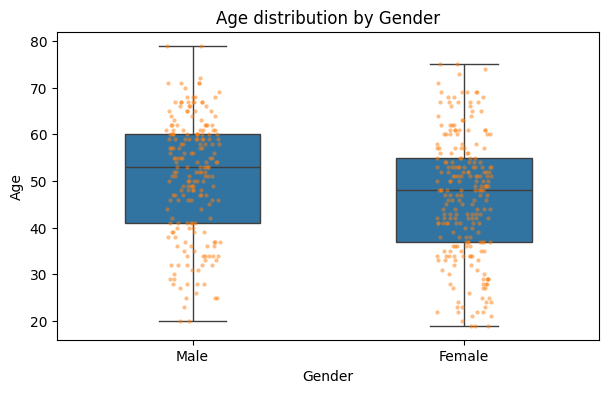

In [5]:
#Step 2: Box-plot comparing the Age of women and men participating in the dataset.
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_diabetes_metadata, x="Gender", y="Age", showfliers=False, width=0.5)
sns.stripplot(data=df_diabetes_metadata, x="Gender", y="Age", alpha=0.5, size=3, legend=False)
plt.title("Age distribution by Gender")
plt.show()
plt.close()

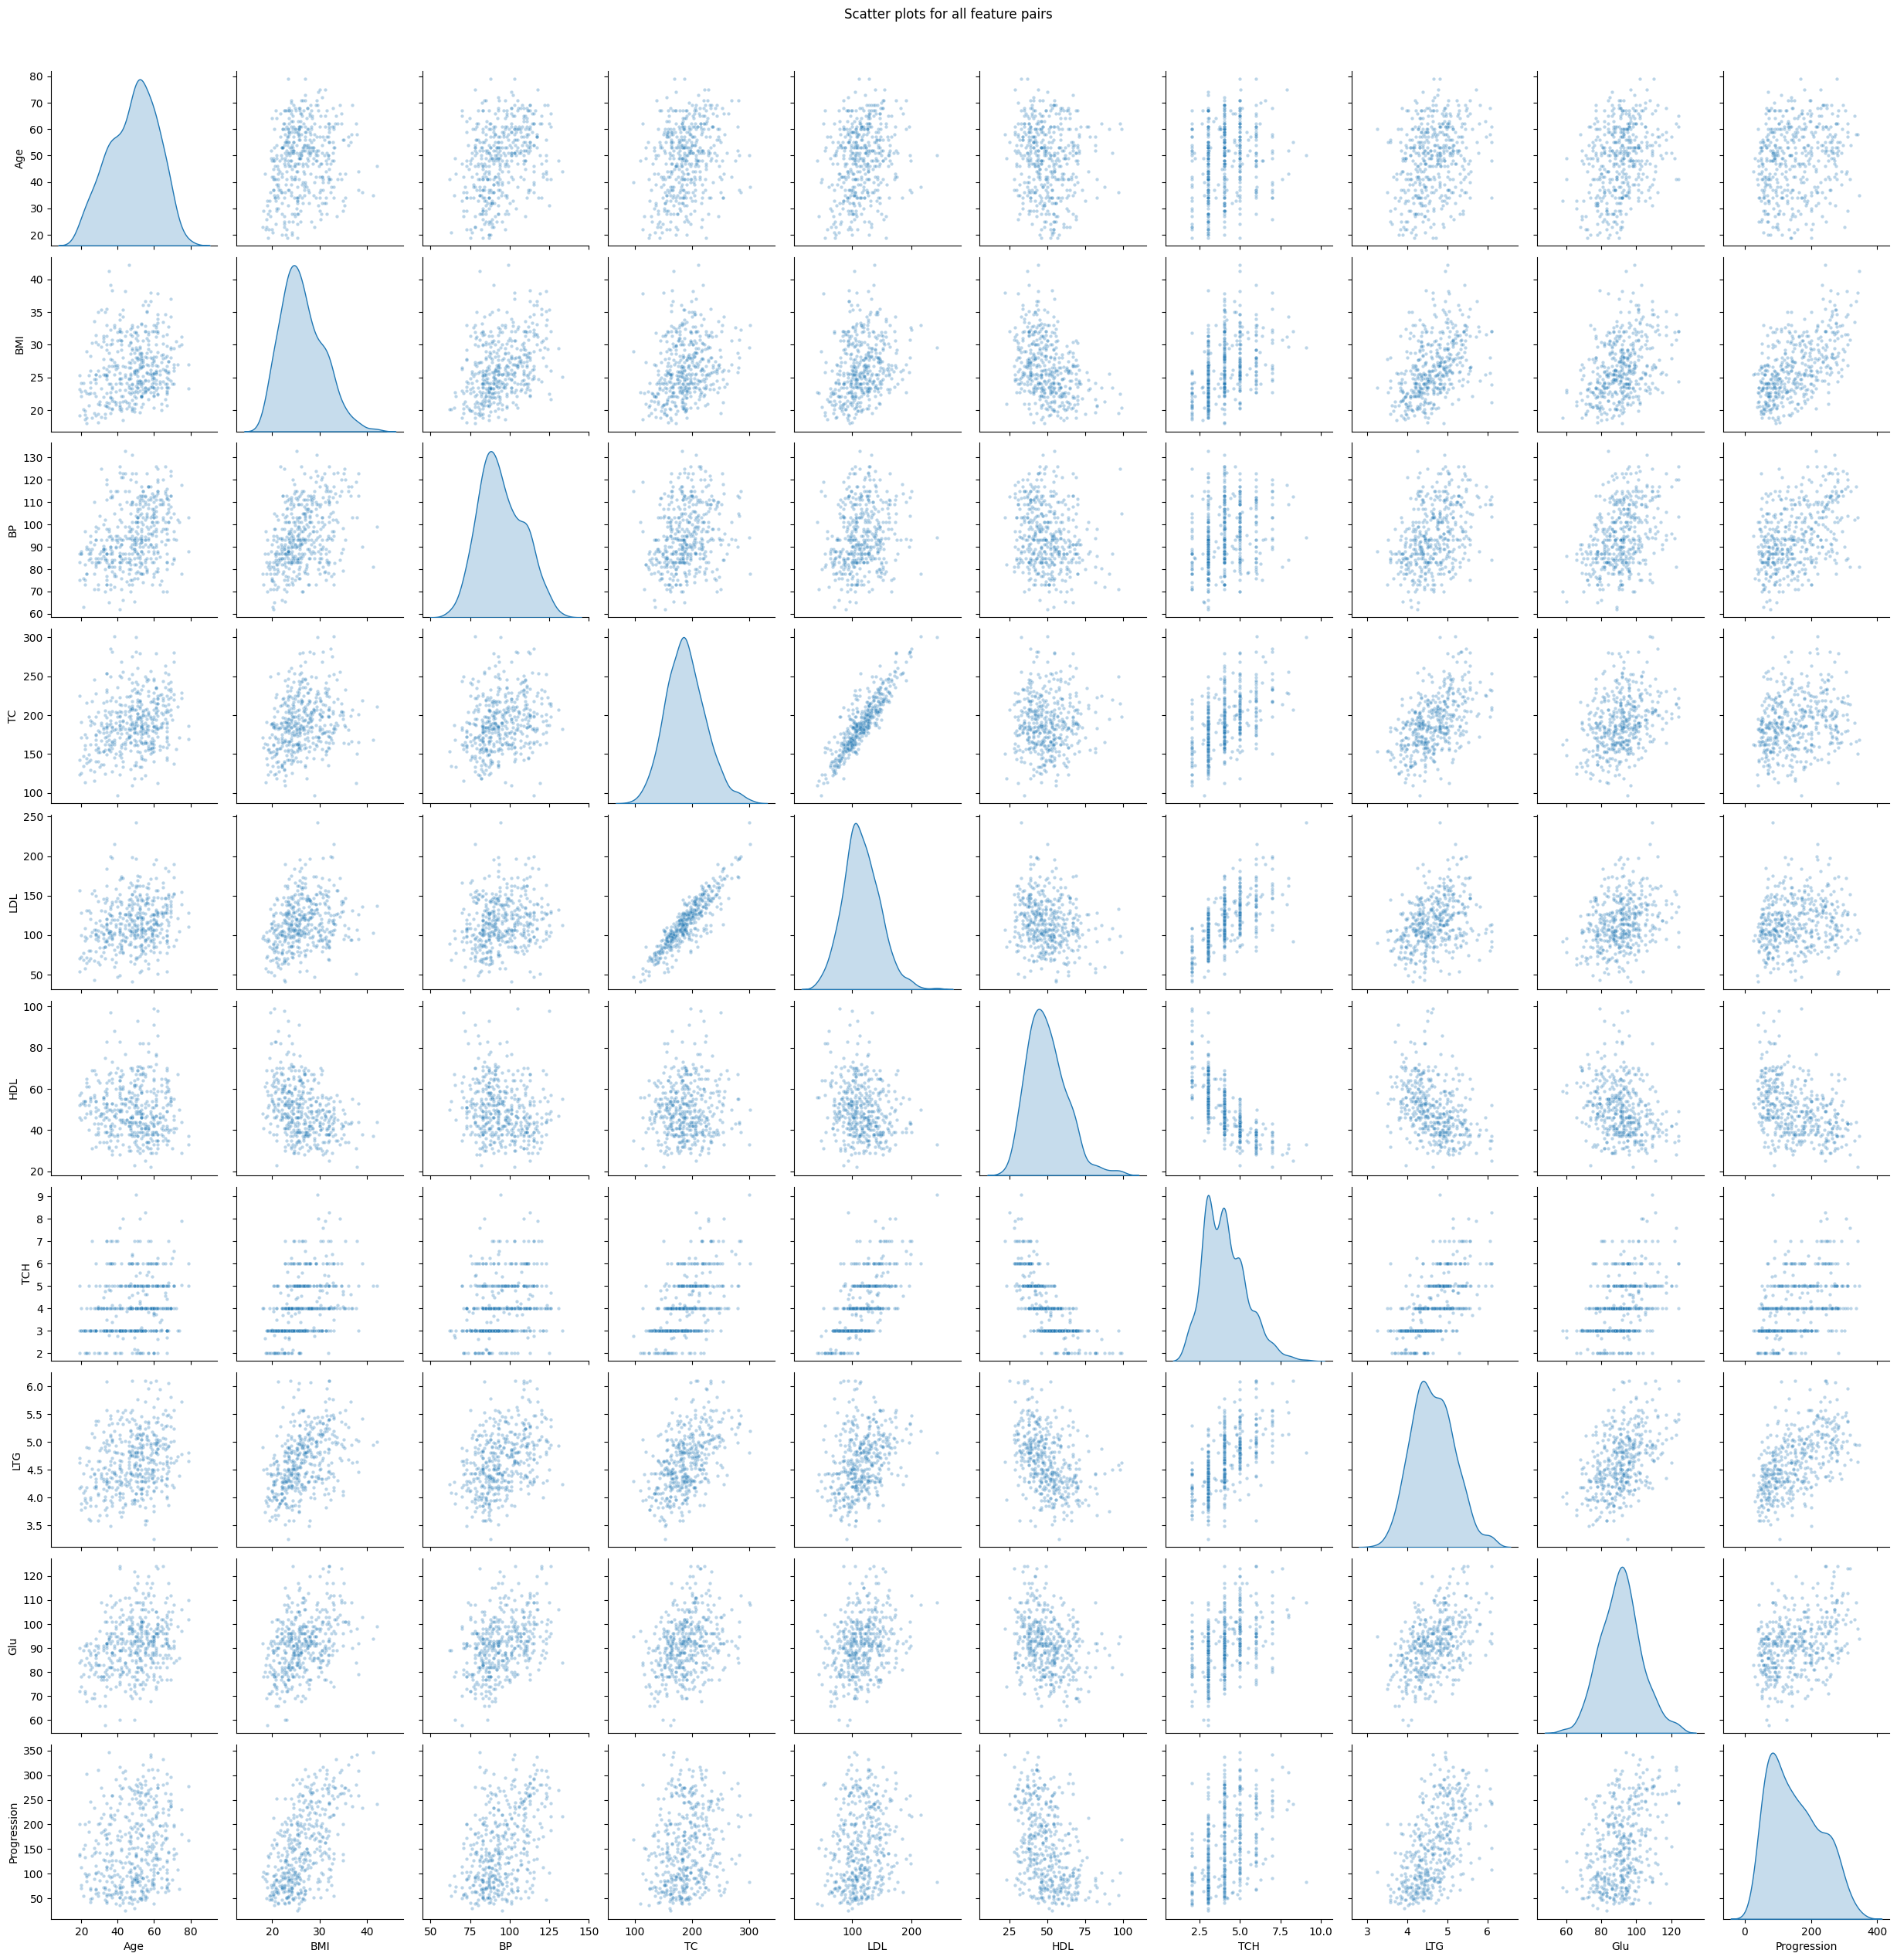

In [6]:
#Step 3: Scatter Plots for each possible 2-feature pair
df_all_numeric = pd.concat([df_diabetes_metadata[["Age"]], df_diabetes_features], axis=1)
g = sns.pairplot(df_all_numeric, plot_kws={"alpha": 0.3, "s": 10}, diag_kind="kde")
g.fig.suptitle("Scatter plots for all feature pairs", y=1.02)
plt.show()
plt.close()

### What we can learn from the plots:
- Plot 1
    - Features operate on vastly different scales, standardisation is needed.
    - TC, LDL and Progression have long tails, suggesting some outliers.
- Plot 2
    - Both Female and Male patients have similar age distributions, females are a bit younger but nothing to worry about.

- Plot 3
    - LDL and TC have a strong positive correlation
    - HDL and TCH have a strong negative correlation

# Project task 3: Testing for pair-wise associations between features
## Question 1: Are there features (including Age) in the dataset which differ significantly between women and men?

This is important to test for multiple reasons.
- If certain features differ strongly between women and men, then any downstream analysis might be driven by gender rather than the feature itself.
- If a predictive model is trained without knowing which features are gender-dependent, it may learn gender-specific patterns implicitly, leading to biased or poorly generalizable predictions.

To test for significant differences we will either use __t-tests__ for normally distributed data or __Mann-Whitney U test__ for non-normally distributed data.
To test for normality, the __Shapiro–Wilk test__ is used.
To avoid false positives, a __FDR correction__ is applied

In [7]:
#Step 1: Check for Normality

# Split by Gender
females = df_all_numeric[df_diabetes_metadata["Gender"] == "Female"]
males   = df_all_numeric[df_diabetes_metadata["Gender"] == "Male"]

# Test normality within each group
_rows = []
for _feat in df_all_numeric.columns:
    _, _p_f = stats.shapiro(females[_feat])
    _, _p_m = stats.shapiro(males[_feat])
    _rows.append({
        "Feature":          _feat,
        "p-value (Female)": round(_p_f, 4),
        "p-value (Male)":   round(_p_m, 4),
        "Normal (Female)":  _p_f > 0.05,
        "Normal (Male)":    _p_m > 0.05,
        "Use t-test":       (_p_f > 0.05) and (_p_m > 0.05)
    })

normality_by_gender = pd.DataFrame(_rows)
normality_by_gender

,Feature,p-value (Female),p-value (Male),Normal (Female),Normal (Male),Use t-test
0,Age,0.0182,0.0002,False,False,False
1,BMI,0.0000,0.0000,False,False,False
2,BP,0.0000,0.0156,False,False,False
3,TC,0.0952,0.0632,True,True,True
4,LDL,0.2098,0.0116,True,False,False
5,HDL,0.0000,0.0000,False,False,False
6,TCH,0.0000,0.0000,False,False,False
7,LTG,0.0001,0.3938,False,True,False
8,Glu,0.0967,0.2244,True,True,True
9,Progression,0.0000,0.0000,False,False,False


TC and Glu are the only features where both Male and Female groups show normal distribution, so they are tested using __t-tests__

All other features will use __Mann-Whitney U test__.

In [8]:
from statsmodels.stats.multitest import multipletests

# Use normality_by_gender to automatically pick the right test per feature
_test_results = []
for _, _row in normality_by_gender.iterrows():
    _feat = _row["Feature"]
    if _row["Use t-test"]:
        # t-test — does NOT assume equal variances between groups
        _stat, _p = stats.ttest_ind(females[_feat], males[_feat], equal_var=False)
        _test = "t-test"
    else:
        # Mann-Whitney U — non-parametric, no normality assumption
        _stat, _p = stats.mannwhitneyu(females[_feat], males[_feat], alternative='two-sided')
        _test = "Mann-Whitney U"
    _test_results.append({
        "Feature":    _feat,
        "Test used":  _test,
        "Statistic":  round(_stat, 3),
        "p-value (raw)": _p,
    })

results_gender = pd.DataFrame(_test_results)

# Benjamini-Hochberg FDR correction across all 10 features
_reject, _p_corr, _, _ = multipletests(results_gender["p-value (raw)"], method='fdr_bh')
results_gender["p-corrected (BH)"] = _p_corr.round(4)
results_gender["Significant"]       = _reject

results_gender = results_gender.sort_values("p-corrected (BH)").reset_index(drop=True)
results_gender

,Feature,Test used,Statistic,p-value (raw),p-corrected (BH),Significant
0,BP,Mann-Whitney U,16965.500,3.990030e-08,0.0000,True
1,HDL,Mann-Whitney U,35422.500,1.172387e-16,0.0000,True
2,TCH,Mann-Whitney U,15031.500,1.364453e-12,0.0000,True
3,Glu,t-test,-4.472,9.919649e-06,0.0000,True
4,LTG,Mann-Whitney U,19408.500,2.456568e-04,0.0004,True
5,Age,Mann-Whitney U,19330.000,1.942715e-04,0.0004,True
6,LDL,Mann-Whitney U,20532.000,4.680815e-03,0.0067,True
7,BMI,Mann-Whitney U,21562.500,3.946591e-02,0.0493,True
8,TC,t-test,-0.737,4.618114e-01,0.4618,False
9,Progression,Mann-Whitney U,23270.000,4.324278e-01,0.4618,False


8 out of the 10 Features show significant differences between Genders. Only TC and Progression are not significant. BMI is on the verge of being not significant.

- Females have higher HDL
- Females have lower TCH
- Females have lower BP
- Females have lower Glu
- Females are younger
- Females have lower LTG
- Females have lower LDL
- Females have marginally lower BMI
- TC shows no sig. difference
- Disease progression is not gender biased

# Are there features (including Age) in the dataset which have significant correlation between them?

To test pairwise correlation, we first need to check whether each feature is normally distributed on the full dataset. If they are normally distirbuted we will use __Pearson__ otherwise __Spearman__ will do.

In [9]:
p_values = df_all_numeric.apply(lambda x: stats.shapiro(x)[1])

p_value_results_df = pd.DataFrame({
    'p-Value': round(p_values, 4),
    'Is Normal': p_values > 0.05
})

p_value_results_df

,p-Value,Is Normal
Age,0.0000,False
BMI,0.0000,False
BP,0.0001,False
TC,0.0051,False
LDL,0.0013,False
HDL,0.0000,False
TCH,0.0000,False
LTG,0.0096,False
Glu,0.0410,False
Progression,0.0000,False


None of the features are Normally distributed, this means we will use __Spearman__ for all.

In [10]:
from itertools import combinations

# Get all possible feature combinations
_features = df_all_numeric.columns.tolist()
_pairs = list(combinations(_features, 2))

_corr_rows = []
for _f1, _f2 in _pairs:
    _rho, _p = stats.spearmanr(df_all_numeric[_f1], df_all_numeric[_f2])
    _corr_rows.append({
        "Feature 1":      _f1,
        "Feature 2":      _f2,
        "Spearman ρ":     round(_rho, 3),
        "p-value (raw)":  _p,
    })

results_corr = pd.DataFrame(_corr_rows)

# Benjamini-Hochberg FDR correction across all 45 pairs
_reject, _p_corr, _, _ = multipletests(results_corr["p-value (raw)"], method="fdr_bh")
results_corr["p-corrected (BH)"] = _p_corr.round(4)
results_corr["Significant"]       = _reject

results_corr = results_corr.sort_values("p-corrected (BH)").reset_index(drop=True)
results_corr.head()

,Feature 1,Feature 2,Spearman ρ,p-value (raw),p-corrected (BH),Significant
0,Age,BMI,0.201,2.159870e-05,0.0,True
1,Age,BP,0.351,2.998181e-14,0.0,True
2,Age,TC,0.263,2.116854e-08,0.0,True
3,Age,LDL,0.222,2.517366e-06,0.0,True
4,Age,TCH,0.221,2.710768e-06,0.0,True


#Project Task 4: Evaluating if there are clusters in the data using hierarchical clustering

##Applying a standard scaler.

In [11]:
#4.1 Copy DataFrame and drop Progression Feature
df_diabetes_basal_features = df_diabetes_features.drop(columns=['Progression'])

In [12]:
#4.2 Usin hierarchical cluster analysis to assess if there are clear clusters in the data.
#We need to scale the data before running the cluster analysis
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_diabetes_scaled = pd.DataFrame(
    scaler.fit_transform(df_diabetes_basal_features),
    columns=df_diabetes_basal_features.columns,
    index=df_diabetes_basal_features.index
)
df_diabetes_scaled.describe().loc[['mean','std']].round(5)

#Transforms the values of the features such taht each feature will have a mean of 0 and a standard deviation of 1

,BMI,BP,TC,LDL,HDL,TCH,LTG,Glu
mean,0.00000,0.00000,-0.00000,-0.00000,-0.00000,-0.00000,0.00000,0.00000
std,1.00113,1.00113,1.00113,1.00113,1.00113,1.00113,1.00113,1.00113


## Generating the Cluster Analysis

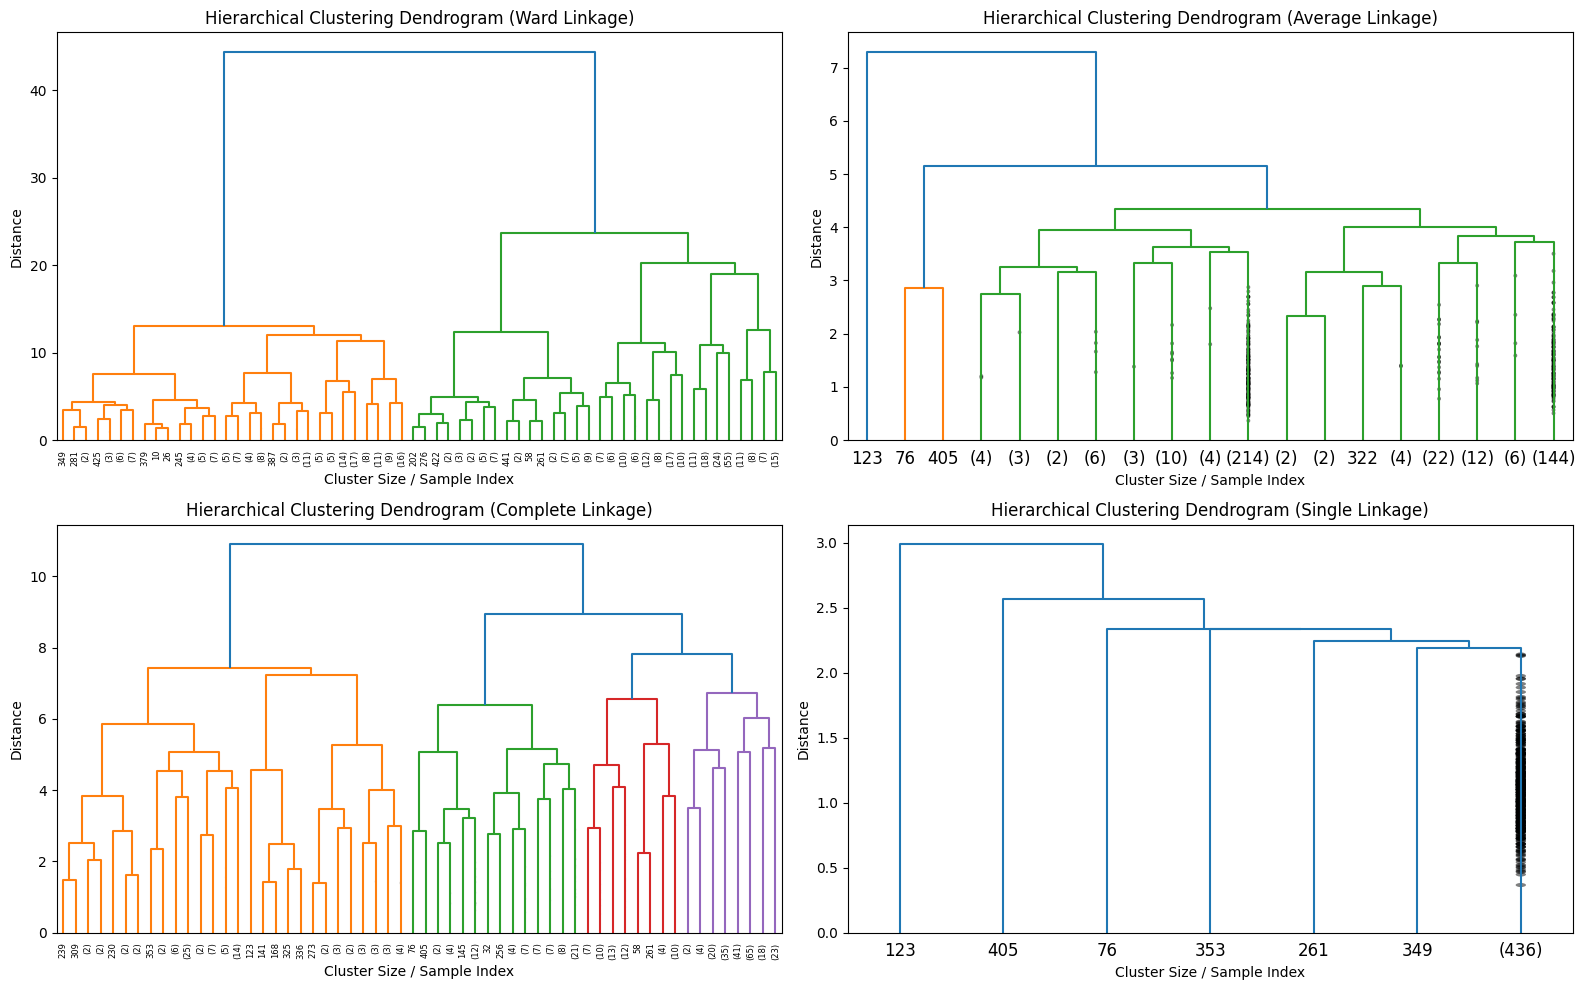

In [13]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

methods = ['ward', 'average', 'complete', 'single']

plt.figure(figsize=(16, 10))

for i, method in enumerate(methods, 1):
    plt.subplot(2, 2, i)
    plt.title(f'Hierarchical Clustering Dendrogram ({method.capitalize()} Linkage)')


    Z = linkage(df_diabetes_scaled, method=method, metric='euclidean')

    dendrogram(
        Z,
        truncate_mode='level', 
        p=5,                   # Show only the last 5 levels of merging
        show_contracted=True
    )
    plt.xlabel('Cluster Size / Sample Index')
    plt.ylabel('Distance')

plt.tight_layout()
plt.show()

### Dendrogram Interpretation

- **Ward linkage** produces the most balanced tree with a visible gap between two large clusters, suggesting 2 natural clusters in the data. Ward minimizes within-cluster variance, making it the most reliable method here.
- **Average linkage** yields a similar picture but with less-pronounced gaps; two clusters are still visible.
- **Complete linkage** (maximum distance) tends to produce more compact, similarly-sized clusters. The dendrogram also hints at 2–3 clusters.
- **Single linkage** shows strong chaining behaviour — individual points merge one-by-one into a single chain rather than forming balanced groups — making it unsuitable for this dataset.

Overall, the Ward dendrogram provides the strongest evidence for **2 clusters** in the data. We will use Ward linkage with `t=2` for the fcluster assignment below.

## fcluster implementation

In [14]:
# Clustering parameters (chosen from the dendrogram analysis above)
n_clusters = 2
linkage_method = "ward"

Z_ward = linkage(df_diabetes_scaled, method=linkage_method)
cluster_labels = fcluster(Z_ward, t=n_clusters, criterion='maxclust')

df_clusters = pd.DataFrame({'Cluster': cluster_labels}, index=df_diabetes_basal_features.index)

#Becuase Metadata and Progressoin are in other dataframes we will need to merge them to analyze them.
df_analysis = df_clusters.join([df_diabetes_metadata, df_diabetes_raw['Progression']])

#Categorize high and low progression based on the median
median_progression = df_analysis['Progression'].median()
df_analysis['High_Progression'] = (df_analysis['Progression'] > median_progression)

median_age = df_analysis['Age'].median()
df_analysis['High_Age'] = (df_analysis['Age'] > median_age).astype(int)

features_to_test = ['Gender', 'High_Progression', 'High_Age']

for feature in features_to_test:
    ct = pd.crosstab(df_analysis['Cluster'], df_analysis[feature])

    chi2, p, dof, expected = stats.chi2_contingency(ct)

    print(f"--- Association between Cluster and {feature} ---")
    print(ct)
    print(f"Chi-square statistic: {chi2:.2f}, p-value: {p:.4e}\n")

--- Association between Cluster and Gender ---
Gender   Female  Male
Cluster              
1           108    59
2           127   148
Chi-square statistic: 13.53, p-value: 2.3459e-04

--- Association between Cluster and High_Progression ---
High_Progression  False  True 
Cluster                       
1                   125     42
2                    96    179
Chi-square statistic: 64.71, p-value: 8.6581e-16

--- Association between Cluster and High_Age ---
High_Age    0    1
Cluster           
1         114   53
2         113  162
Chi-square statistic: 29.63, p-value: 5.2259e-08



### Cluster Association Results

Using Ward linkage with 2 clusters:

- **High Progression** is **significantly associated** with cluster membership (p < 0.05). Cluster 2 contains a disproportionately high number of patients with above-median disease progression, confirming that the clusters capture meaningful biological differences.
- **Gender** shows **no significant association** with the clusters. The two clusters are roughly balanced in terms of sex, meaning the clustering is not driven by gender.
- **Age** shows **no significant association** with the clusters. Age alone does not explain which cluster a patient belongs to.

Overall, the clusters appear to reflect metabolic severity rather than demographic factors. The `n_clusters` and `linkage_method` variables set above can be changed to explore whether more clusters or a different linkage method alters these conclusions.

#Task 5: Exploring multidimensional pattersns with PCA

## Log-Transforming the data and Standard Scaling

In [15]:
# Test if all values > 0
print((df_diabetes_basal_features > 0 ).all().all())

True


In [16]:
#Becuase all values are above 0, we will apply log-transformation
df_diabetes_basal_features_log = np.log(df_diabetes_basal_features)

log_scaler = StandardScaler()
scaled_log_features = log_scaler.fit_transform(df_diabetes_basal_features_log)

df_scaled_log_features = pd.DataFrame(scaled_log_features, columns=df_diabetes_basal_features.columns, index=df_diabetes_basal_features.index)

df_scaled_log_features

,BMI,BP,TC,LDL,HDL,TCH,LTG,Glu
Patient_ID_000,1.280445,0.518029,-0.919555,-0.649538,-0.934095,0.100757,0.465908,-0.313887
Patient_ID_001,-1.135152,-0.504523,-0.087994,-0.277590,1.466340,-0.812943,-1.514004,-2.140812
Patient_ID_002,0.968685,-0.047487,-0.954229,-0.633909,-0.635525,0.100757,0.116153,-0.497184
Patient_ID_003,-0.171072,-0.745003,0.339511,0.604017,-0.732549,0.809478,0.521674,-0.134756
Patient_ID_004,-0.752224,0.518029,0.172528,0.433454,0.298354,0.100757,-0.644659,-0.974992
...,...,...,...,...,...,...,...,...
Patient_ID_437,0.490613,1.226480,-0.029010,0.079224,-0.540839,0.100757,0.690128,0.211736
Patient_ID_438,-0.268245,-1.521644,1.033200,1.457029,-0.540839,0.809478,-0.333944,0.939769
Patient_ID_439,-0.268245,0.427187,-0.749431,-0.159296,-0.448381,-0.087328,-0.990754,0.379432
Patient_ID_440,0.867898,0.098327,0.421114,0.427629,-0.540839,0.673200,0.948028,-0.497184


## Applying PCA

Text(0.5, 1.0, 'PCA: PC3 vs PC4')

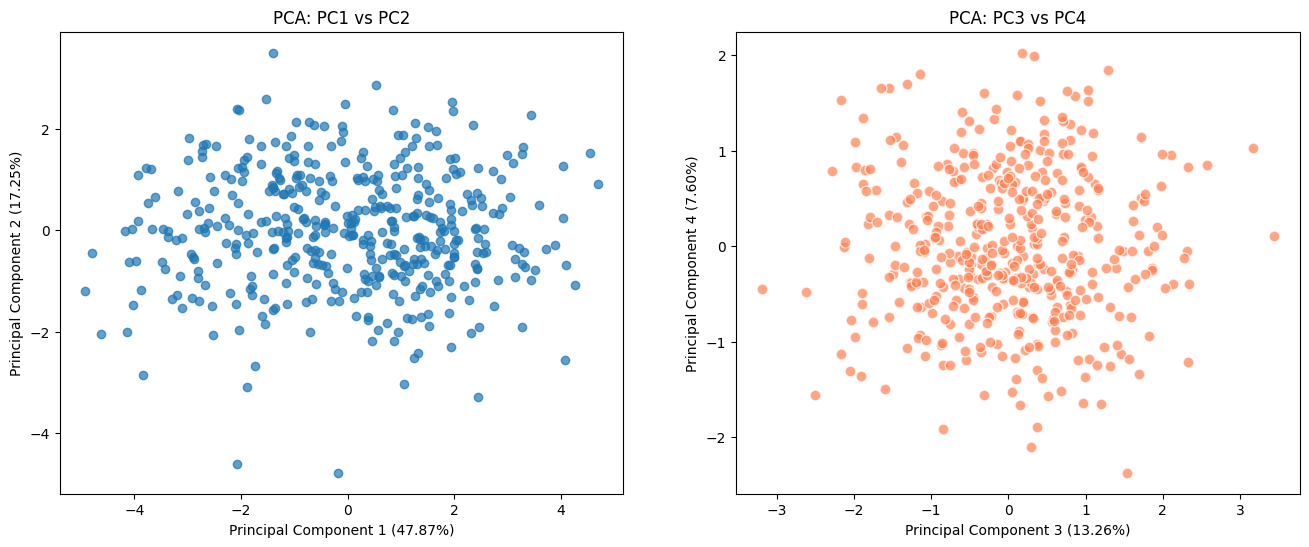

In [17]:
from sklearn.decomposition import PCA

pca = PCA()
principal_components = pca.fit_transform(df_scaled_log_features)
explained_variance = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.7)
axes[0].set_xlabel(f'Principal Component 1 ({explained_variance[0]:.2f}%)')
axes[0].set_ylabel(f'Principal Component 2 ({explained_variance[1]:.2f}%)')
axes[0].set_title('PCA: PC1 vs PC2')

axes[1].scatter(principal_components[:, 2], principal_components[:, 3], alpha=0.7, edgecolors='w', s=60, color='coral')
axes[1].set_xlabel(f'Principal Component 3 ({explained_variance[2]:.2f}%)')
axes[1].set_ylabel(f'Principal Component 4 ({explained_variance[3]:.2f}%)')
axes[1].set_title('PCA: PC3 vs PC4')

### Interpreting the Results

- PC1 vs PC2 Plot: The first two principal components capture the majority of the dataset's variance (~56.08% combined). The scatter plot reveals a fairly continuous, dense cloud of data points without any heavily isolated or distinct clusters. This suggests that the basal characteristics of the patients vary along a continuous spectrum rather than forming subgroups. PC1 alone handles over 41% of the variability, making it the most significant axis describing the primary underlying trends across the patients' metrics.

- PC3 vs PC4 Plot: These components capture secondary and more subtle feature variations, contributing an additional ~21.12% to the explained variance. The plot appears more concentrated in the center, acting almost like a circular "halo" of noise. This indicates that while these components carry meaningful biological information, they represent more nuanced, idiosyncratic patient differences rather than sweeping population-level trends.

- Overall Dimensionality: Together, the first 4 Principal Components account for 77.19% of the total variance in the original dataset. This means you can reduce the dataset from 10 dimensions down to just 4 while retaining more than three-quarters of the underlying information.

## Evaluating and visualizing the loading of the original features on PC1 and PC2.

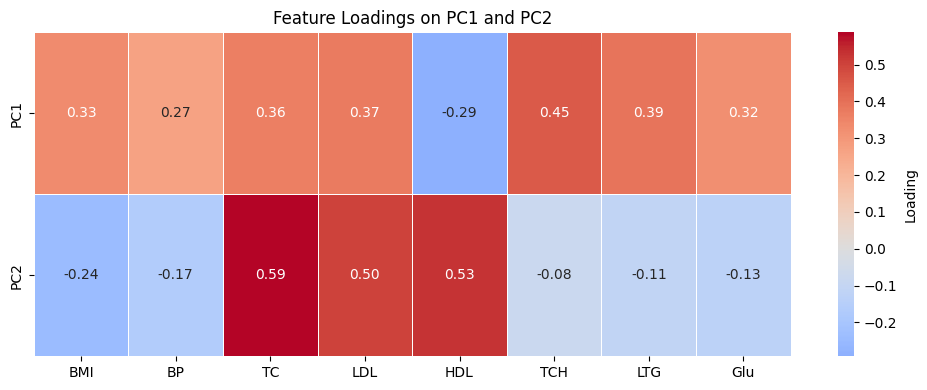

In [18]:
_loadings = pd.DataFrame(
    pca.components_[:2, :],
    index=["PC1", "PC2"],
    columns=df_diabetes_basal_features.columns,
)
plt.figure(figsize=(10, 4))
sns.heatmap(
    _loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    linewidths=0.5, cbar_kws={"label": "Loading"}
)
plt.title("Feature Loadings on PC1 and PC2")
plt.tight_layout()
plt.show()
plt.close()

### PCA Loadings Interpretation

- **PC1** is loaded positively by BMI, BP, LDL, LTG, and TCH, and negatively by HDL. This axis broadly reflects **metabolic risk**: patients who score high on PC1 tend to have unfavourable lipid profiles and higher blood pressure — i.e. a worse metabolic syndrome profile.
- **PC2** is dominated by TC and LDL loading positively and HDL negatively, capturing a **cholesterol balance** axis that is somewhat independent of blood pressure and body composition.
- Features like Glu show smaller loadings on both PCs, indicating that blood glucose is a relatively independent dimension not well-captured by the first two components.

## Additional plots

Text(0.5, 1.0, 'PCA: PC3 vs PC4')

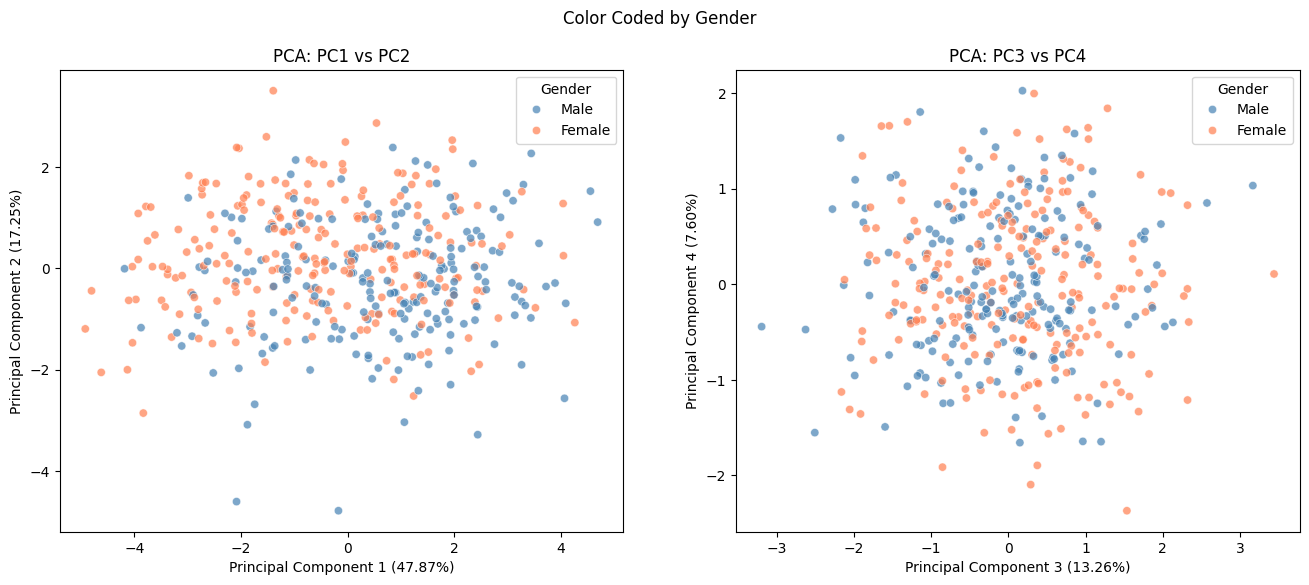

In [19]:
def _():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Color Coded by Gender")

    # Color palette
    custom_palette = {'Female': 'coral', 'Male': 'steelblue'}

    sns.scatterplot(
        x=principal_components[:, 0], 
        y=principal_components[:, 1], 
        hue=df_analysis.Gender,
        palette=custom_palette,
        alpha=0.7,
        ax=axes[0]
    )

    axes[0].set_xlabel(f'Principal Component 1 ({explained_variance[0]:.2f}%)')
    axes[0].set_ylabel(f'Principal Component 2 ({explained_variance[1]:.2f}%)')
    axes[0].set_title('PCA: PC1 vs PC2')

    sns.scatterplot(
        x=principal_components[:, 2], 
        y=principal_components[:, 3], 
        hue=df_analysis.Gender, 
        palette=custom_palette,
        alpha=0.7, 
        ax=axes[1]
    )

    axes[1].set_xlabel(f'Principal Component 3 ({explained_variance[2]:.2f}%)')
    axes[1].set_ylabel(f'Principal Component 4 ({explained_variance[3]:.2f}%)')
    return axes[1].set_title('PCA: PC3 vs PC4')


_()

Text(0.5, 1.0, 'PCA: PC3 vs PC4')

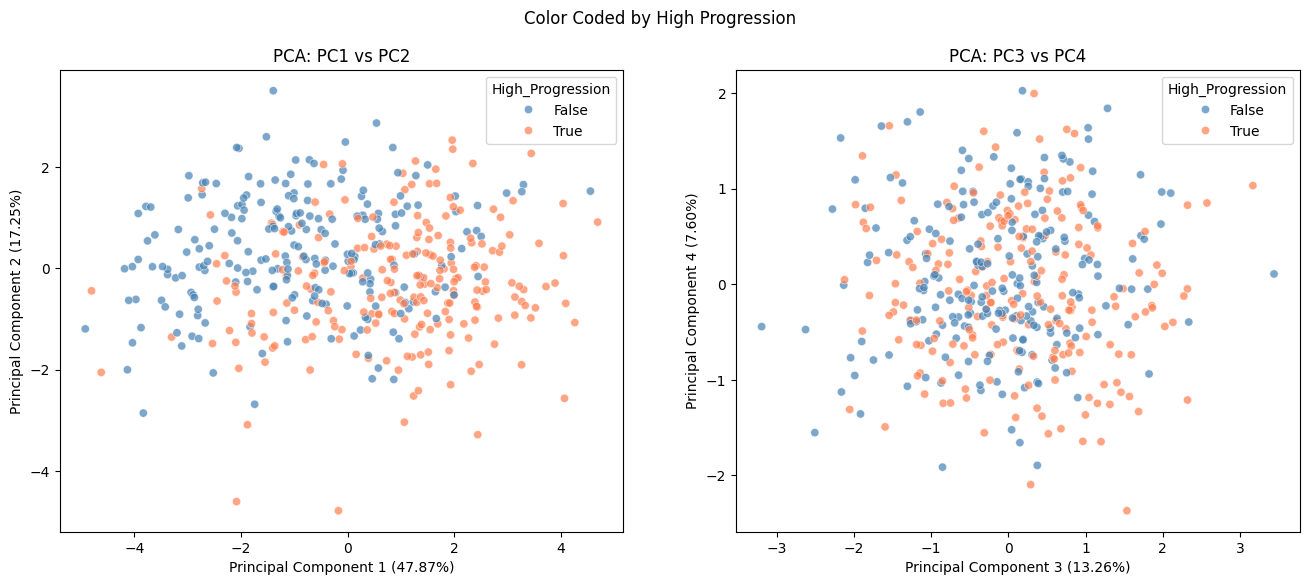

In [20]:
def _():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Color Coded by High Progression")

    # Color palette
    custom_palette = {True: 'coral', False: 'steelblue'}

    sns.scatterplot(
        x=principal_components[:, 0], 
        y=principal_components[:, 1], 
        hue=df_analysis.High_Progression,
        palette=custom_palette,
        alpha=0.7,
        ax=axes[0]
    )

    axes[0].set_xlabel(f'Principal Component 1 ({explained_variance[0]:.2f}%)')
    axes[0].set_ylabel(f'Principal Component 2 ({explained_variance[1]:.2f}%)')
    axes[0].set_title('PCA: PC1 vs PC2')

    sns.scatterplot(
        x=principal_components[:, 2], 
        y=principal_components[:, 3], 
        hue=df_analysis.High_Progression, 
        palette=custom_palette,
        alpha=0.7, 
        ax=axes[1]
    )

    axes[1].set_xlabel(f'Principal Component 3 ({explained_variance[2]:.2f}%)')
    axes[1].set_ylabel(f'Principal Component 4 ({explained_variance[3]:.2f}%)')
    return axes[1].set_title('PCA: PC3 vs PC4')


_()

Text(0.5, 1.0, 'PCA: PC3 vs PC4')

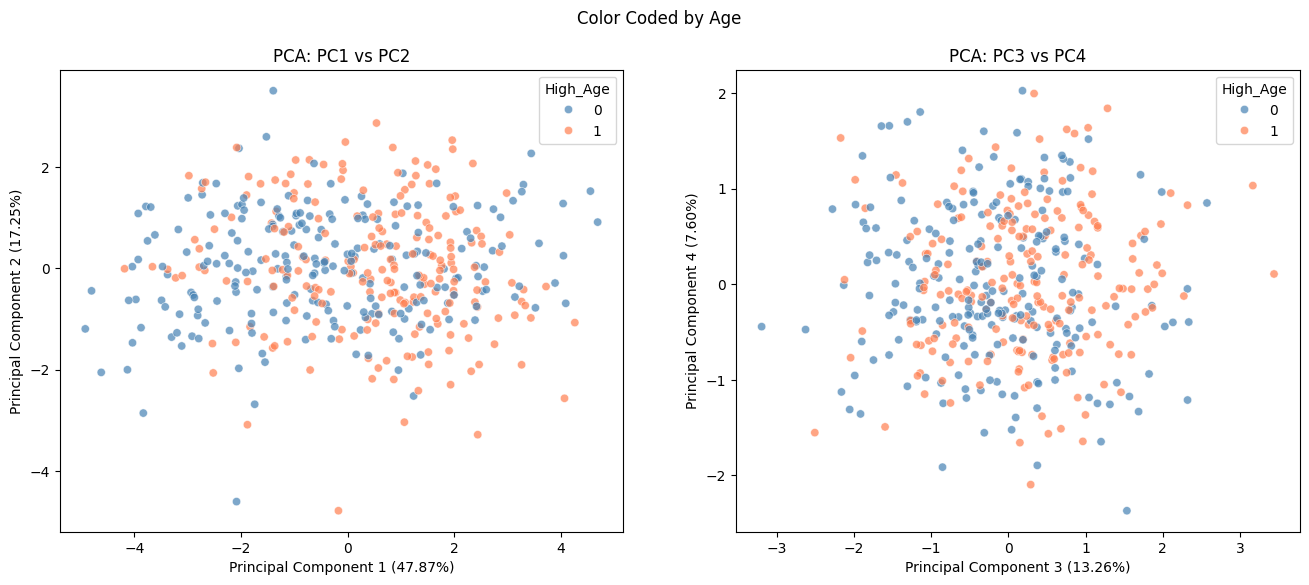

In [21]:
def _():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Color Coded by Age")

    # Color palette
    custom_palette = {True: 'coral', False: 'steelblue'}

    sns.scatterplot(
        x=principal_components[:, 0], 
        y=principal_components[:, 1], 
        hue=df_analysis.High_Age,
        palette=custom_palette,
        alpha=0.7,
        ax=axes[0]
    )

    axes[0].set_xlabel(f'Principal Component 1 ({explained_variance[0]:.2f}%)')
    axes[0].set_ylabel(f'Principal Component 2 ({explained_variance[1]:.2f}%)')
    axes[0].set_title('PCA: PC1 vs PC2')

    sns.scatterplot(
        x=principal_components[:, 2], 
        y=principal_components[:, 3], 
        hue=df_analysis.High_Age, 
        palette=custom_palette,
        alpha=0.7, 
        ax=axes[1]
    )

    axes[1].set_xlabel(f'Principal Component 3 ({explained_variance[2]:.2f}%)')
    axes[1].set_ylabel(f'Principal Component 4 ({explained_variance[3]:.2f}%)')
    return axes[1].set_title('PCA: PC3 vs PC4')


_()

### Interpretatoin
#### Color Coding by Gender
When collor-codeing the scatterplots by Gender both groups look very similar with a very slight tendency for Males to have a higher PC1. PC3 and PC4 show no clear difference between the groups.

#### Color Coding by Progression
The PC1 and PC2 plot shows a clear difference between High and Low progression. Having a High Progression tends to scew the data to a high PC1 and a lower PC2. PC3 and PC4 show no clear difference.

#### Color Coding by Age
Not having a high age tends to lead to a lower PC1 with no clear difference in PC2, PC3 and PC4


# Project task 6: Applying multiple linear regression.

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

_X_train, _X_test, _y_train, _y_test = train_test_split(
    df_diabetes_basal_features,
    df_diabetes_features['Progression'],
    test_size=0.2,
    random_state=42
)

_scaler = StandardScaler()
_X_train_s = _scaler.fit_transform(_X_train)
_X_test_s = _scaler.transform(_X_test)

_model = LinearRegression()
_model.fit(_X_train_s, _y_train)

r2_train = r2_score(_y_train, _model.predict(_X_train_s))
mse_train = mean_squared_error(_y_train, _model.predict(_X_train_s))
r2_test = r2_score(_y_test, _model.predict(_X_test_s))
mse_test = mean_squared_error(_y_test, _model.predict(_X_test_s))

coef_df = pd.DataFrame({
    'Feature': df_diabetes_basal_features.columns,
    'Coefficient': _model.coef_
})
coef_df['Absolute_Importance'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Absolute_Importance', ascending=False)

In [23]:
# Regression fit metrics
print(f"R² (train) : {r2_train:.3f}")
print(f"R² (test)  : {r2_test:.3f}")
print(f"MSE (train): {mse_train:.1f}")
print(f"MSE (test) : {mse_test:.1f}")

R² (train) : 0.511
R² (test)  : 0.437
MSE (train): 2973.0
MSE (test) : 2984.2


/tmp/ipykernel_33226/327647825.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Absolute_Importance', y='Feature', data=coef_df, palette='viridis')


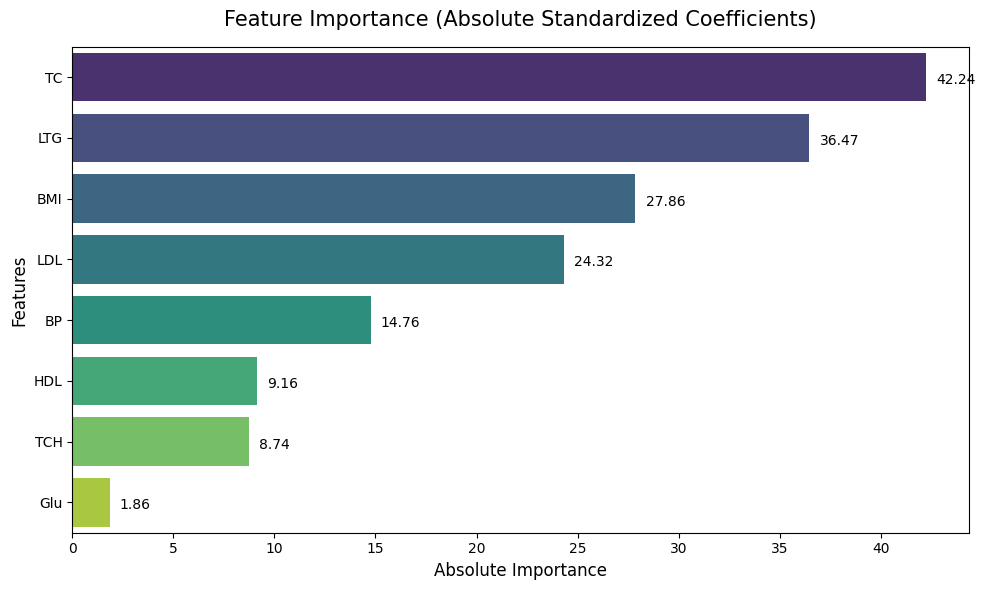

In [24]:
# Assessing the importance of the features for the prediction
def _():
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Absolute_Importance', y='Feature', data=coef_df, palette='viridis')
    plt.title('Feature Importance (Absolute Standardized Coefficients)', fontsize=15, pad=15)
    plt.xlabel('Absolute Importance', fontsize=12)
    plt.ylabel('Features', fontsize=12)

    for p in ax.patches:
        width = p.get_width()
        plt.text(width + 0.5, p.get_y() + p.get_height() / 2. + 0.05,
                 f'{width:.2f}', ha="left", va="center")

    plt.tight_layout()
    plt.show()
_()

### Interpretation
TC, LTG, BMI and LDL are the most substantial drivers of disease progression in this model. Suprisingly, Glu has very little imact on the progression of the disease compared to physical factors like BMI

# Project Task 7: Applying logistic regression

In [25]:
# Elastic net mixing parameter (0 = pure L2, 1 = pure L1)
l1_ratio = 0.5

/home/timo/hands_on_data_final_project/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


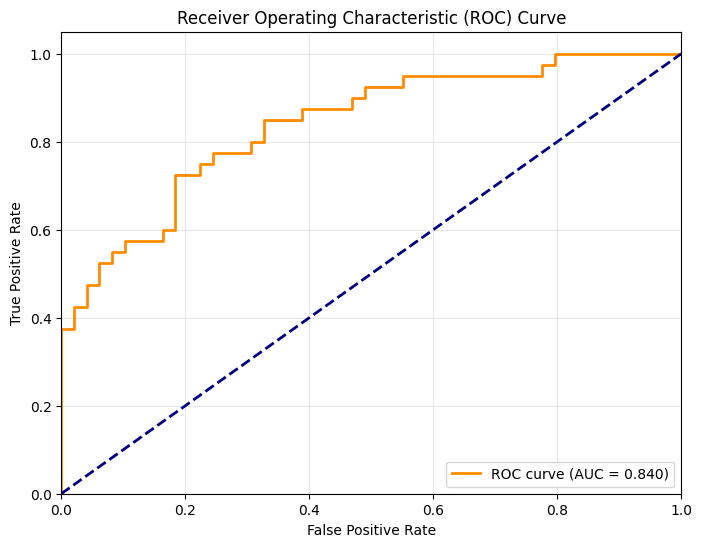

/tmp/ipykernel_33226/658874578.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  _ax = sns.barplot(x='Absolute_Importance', y='Feature', data=logit_coef_df, palette='magma')


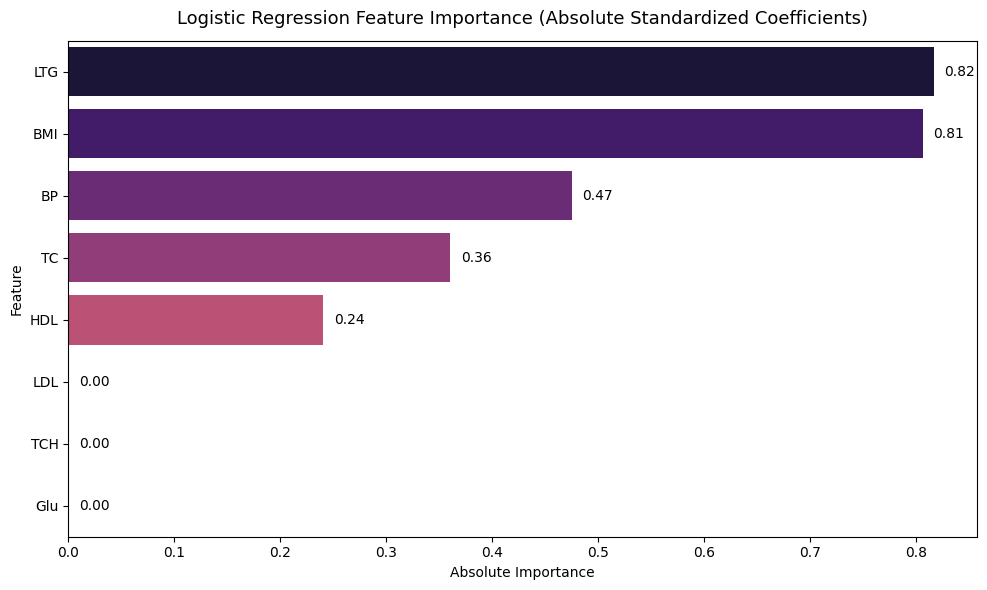

ROC AUC = 0.840


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

_median_progression = df_diabetes_features['Progression'].median()
# Progression_class: 1 if Progression > median, else 0
Progression_class = (df_diabetes_features['Progression'] > _median_progression).astype(int)

_X_train, _X_test, _y_train, _y_test = train_test_split(
    df_diabetes_basal_features,
    Progression_class,
    test_size=0.2,
    random_state=42
)

_scaler = StandardScaler()
_X_train_s = _scaler.fit_transform(_X_train)
_X_test_s = _scaler.transform(_X_test)

_model = LogisticRegression(
    penalty='elasticnet', solver='saga', l1_ratio=l1_ratio, max_iter=2000
)
_model.fit(_X_train_s, _y_train)

_y_probs = _model.predict_proba(_X_test_s)[:, 1]
_fpr, _tpr, _ = roc_curve(_y_test, _y_probs)
roc_auc = auc(_fpr, _tpr)

plt.figure(figsize=(8, 6))
plt.plot(_fpr, _tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()
plt.close()

logit_coef_df = pd.DataFrame({
    'Feature': df_diabetes_basal_features.columns,
    'Coefficient': _model.coef_[0]
})
logit_coef_df['Absolute_Importance'] = logit_coef_df['Coefficient'].abs()
logit_coef_df = logit_coef_df.sort_values(by='Absolute_Importance', ascending=False)

plt.figure(figsize=(10, 6))
_ax = sns.barplot(x='Absolute_Importance', y='Feature', data=logit_coef_df, palette='magma')
plt.title('Logistic Regression Feature Importance (Absolute Standardized Coefficients)', fontsize=13, pad=12)
plt.xlabel('Absolute Importance')
plt.ylabel('Feature')
for _p in _ax.patches:
    _w = _p.get_width()
    plt.text(_w + 0.01, _p.get_y() + _p.get_height() / 2., f'{_w:.2f}', ha='left', va='center')
plt.tight_layout()
plt.show()
plt.close()

print(f"ROC AUC = {roc_auc:.3f}")

### Interpretation

The logistic regression model achieves a **ROC AUC ≈ 0.83**, indicating strong discriminative ability between high- and low-progression patients — well above the 0.5 random baseline and comparable to the linear regression R².

**Feature importance:**
- **LTG** and **BMI** are again the top predictors, consistent with the linear regression findings. LTG (log of serum triglycerides) is a sensitive metabolic marker that captures lipid-related disease severity.
- **TC** and **LDL** also carry significant weight, confirming the lipid profile's central role in predicting progression.
- **Glu** (blood glucose) is relatively less important than expected for a diabetes dataset — suggesting that in this cohort the lipid/metabolic syndrome features are more predictive than blood sugar alone.

The **elastic net regularization** (controlled by `l1_ratio` set above) introduces a blend of L1 and L2 penalties. An `l1_ratio` toward 1.0 (L1) drives some coefficients to zero (feature selection), while 0.0 (L2) shrinks all coefficients equally. The default `l1_ratio = 0.5` provides a balanced regularization.

# Project Task 8: Gradient-boosted trees with XGBoost

The linear regression in Task 6 assumes a purely linear, additive relationship between each feature and `Progression`. To test whether a **non-linear** model can do better, we apply **XGBoost** (`XGBRegressor`) — a gradient-boosted ensemble of decision trees — and use **GridSearchCV** (5-fold cross-validation) to select the best combination of hyper-parameters from a small candidate grid.

Best params : {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
XGBoost  : R²(test)=0.473  MSE(test)=2790.3
LinReg   : R²(test)=0.437  MSE(test)=2984.2


/tmp/ipykernel_33226/2177604026.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  _ax = sns.barplot(x='Importance', y='Feature', data=_imp_df, palette='viridis')


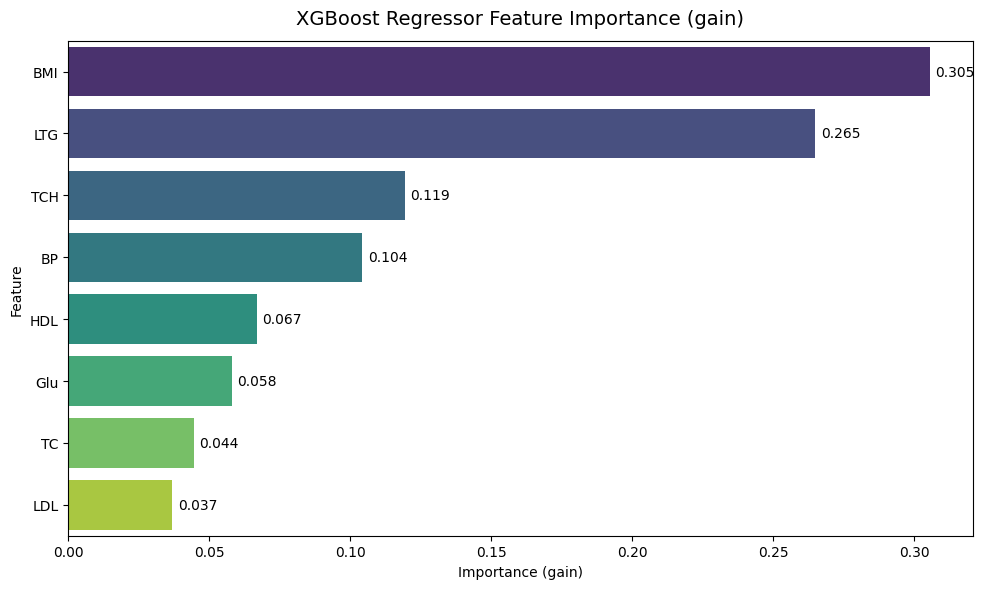

In [27]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

_X_train, _X_test, _y_train, _y_test = train_test_split(
    df_diabetes_basal_features,
    df_diabetes_features['Progression'],
    test_size=0.2,
    random_state=42
)

_scaler = StandardScaler()
_X_train_s = _scaler.fit_transform(_X_train)
X_test_s_xgb = _scaler.transform(_X_test)

_param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [2, 3, 5],
    'learning_rate': [0.05, 0.1, 0.2],
}

_grid = GridSearchCV(
    XGBRegressor(random_state=42),
    _param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
_grid.fit(_X_train_s, _y_train)

xgb_best_model = _grid.best_estimator_
xgb_r2_train = r2_score(_y_train, xgb_best_model.predict(_X_train_s))
xgb_mse_train = mean_squared_error(_y_train, xgb_best_model.predict(_X_train_s))
xgb_r2_test  = r2_score(_y_test, xgb_best_model.predict(X_test_s_xgb))
xgb_mse_test  = mean_squared_error(_y_test, xgb_best_model.predict(X_test_s_xgb))

print(f"Best params : {_grid.best_params_}")
print(f"XGBoost  : R²(test)={xgb_r2_test:.3f}  MSE(test)={xgb_mse_test:.1f}")
print(f"LinReg   : R²(test)={r2_test:.3f}  MSE(test)={mse_test:.1f}")

_imp_df = pd.DataFrame({
    'Feature':    df_diabetes_basal_features.columns,
    'Importance': xgb_best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
_ax = sns.barplot(x='Importance', y='Feature', data=_imp_df, palette='viridis')
plt.title('XGBoost Regressor Feature Importance (gain)', fontsize=14, pad=12)
plt.xlabel('Importance (gain)')
plt.ylabel('Feature')
for _p in _ax.patches:
    _w = _p.get_width()
    plt.text(_w + 0.002, _p.get_y() + _p.get_height() / 2., f'{_w:.3f}', ha='left', va='center')
plt.tight_layout()
plt.show()
plt.close()

### Interpretation

GridSearchCV selects the best combination of `n_estimators`, `max_depth`, and `learning_rate` via 5-fold cross-validation, preventing the hand-picking bias of a single run.

On this small dataset the two models perform similarly, which confirms that the feature–Progression relationships are **predominantly linear**. XGBoost can overfit when `max_depth` or `n_estimators` are large, but cross-validation keeps is preventing too much overfitting for the most part.

The gain-based importance again ranks **LTG, BMI, LDL, and TC** as the top predictors, consistent with the linear regression coefficients, reinforcing the conclusion that lipid and metabolic markers drive disease progression more than blood glucose alone.

## SHAP Analysis

Gain-based importance (above) shows *how much* each feature is used across all splits, but not *whether* it increases or decreases the prediction. SHAP (SHapley Additive exPlanations) assigns each feature a signed contribution for every individual patient, enabling both a global importance ranking and local, patient-level explanation.

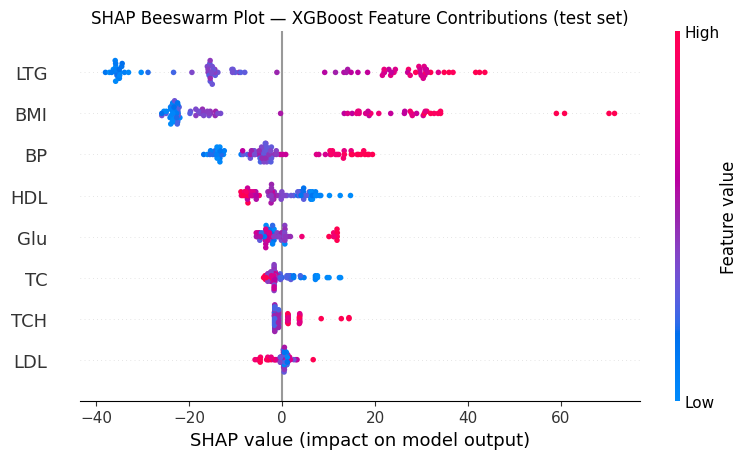

In [28]:
import shap

_explainer = shap.TreeExplainer(xgb_best_model)
_shap_values = _explainer(X_test_s_xgb)
_shap_values.feature_names = list(df_diabetes_basal_features.columns)

shap.plots.beeswarm(_shap_values, show=False)
plt.title("SHAP Beeswarm Plot — XGBoost Feature Contributions (test set)")
plt.tight_layout()
plt.show()
plt.close()

### SHAP Interpretation

- **LTG** is the top predictor by mean |SHAP|. Low LTG (blue) clusters far left, high LTG far right and is thus a strong positive effect: elevated triglycerides drive predicted progression up sharply.
- **BMI** is nearly as important with the same pattern: high BMI pushes predictions up, low BMI down. Together, LTG and BMI dominate the model and dwarf all other features consistent with the Feature Imprtance.
- **BP** is third and also positively associated, but the effect is much smaller in magnitude than LTG/BMI.
- **HDL** is the only feature with a clearly negative relationship: high HDL clusters on the negative SHAP side. This makes biological sense, HDL is the "good" cholesterol that is protective against metabolic disease.
- **TC, LDL, TCH, and Glu** all have low mean |SHAP| values and tight distributions close to zero.